Veri shape: (316800, 27)
Silindi: Country
LogisticRegression Accuracy: 0.6626
RandomForest Accuracy: 0.5542
XGBoost Accuracy: 0.6077

🧠 Confusion Matrix:
[[32567  9727]
 [11653  9413]]


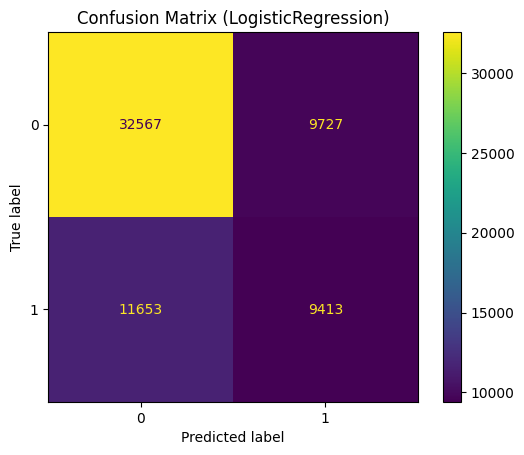


🔥 EN İYİ MODEL: LogisticRegression

✅ MODEL KAYDEDİLDİ (model.pkl)
✅ FEATURE LİSTESİ KAYDEDİLDİ (features.pkl)
✅ SCALER KAYDEDİLDİ (scaler.pkl)


In [11]:
# ================================
# 1. KÜTÜPHANELER
# ================================
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# ================================
# 2. VERİ YÜKLE
# ================================
df = pd.read_csv("Cleaned-Data.csv")

print("Veri shape:", df.shape)

# ================================
# 3. TARGET
# ================================
df["target"] = df["Contact_Yes"]

# STRING TEMİZLE
for col in df.columns:
    if df[col].dtype == "object":
        print("Silindi:", col)
        df = df.drop(col, axis=1)

# LEAKAGE FIX
leak_cols = ["Contact_Yes", "Contact_No", "Contact_DontKnow"]
leak_cols = [col for col in leak_cols if col in df.columns]

X = df.drop(leak_cols + ["target"], axis=1)
y = df["target"]
# ================================
# 4. FEATURE SAVE
# ================================
feature_names = X.columns.tolist()
joblib.dump(feature_names, "features.pkl")

# ================================
# 5. TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 6. SCALE
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

# ================================
# 7. MODELLER
# ================================
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

# ================================
# 8. TRAIN + TEST
# ================================
for name, model in models.items():

    if name == "LogisticRegression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = (model, acc)

    print(f"{name} Accuracy: {acc:.4f}")

# ================================
# CONFUSION MATRIX
# ================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# en iyi modele göre predict
if best_model_name == "LogisticRegression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

print("\n🧠 Confusion Matrix:")
print(cm)

# görsel
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()
# ================================
# 9. EN İYİ MODEL
# ================================
best_model_name = max(results, key=lambda x: results[x][1])
best_model = results[best_model_name][0]

print("\n🔥 EN İYİ MODEL:", best_model_name)

# ================================
# 10. FEATURE IMPORTANCE
# ================================
if hasattr(best_model, "feature_importances_"):
    import matplotlib.pyplot as plt

    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    print("\n🔝 Top 10 Feature:")
    print(feat_imp.head(10))

    plt.figure()
    feat_imp.head(10).plot(kind="barh")
    plt.title("Top 10 Feature")
    plt.gca().invert_yaxis()
    plt.show()

# ================================
# 11. MODEL KAYDET
# ================================
joblib.dump(best_model, "model.pkl")

print("\n✅ MODEL KAYDEDİLDİ (model.pkl)")
print("✅ FEATURE LİSTESİ KAYDEDİLDİ (features.pkl)")
print("✅ SCALER KAYDEDİLDİ (scaler.pkl)")